In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Railway_info.csv")

In [3]:
df.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [4]:
df.shape

(11113, 5)

In [5]:
df.columns

Index(['Train_No', 'Train_Name', 'Source_Station_Name',
       'Destination_Station_Name', 'days'],
      dtype='object')

In [6]:
df.dtypes

Train_No                     int64
Train_Name                  object
Source_Station_Name         object
Destination_Station_Name    object
days                        object
dtype: object

In [7]:
df.isnull().sum()

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64

In [8]:
print(df["Train_No"].nunique())


11113


In [9]:
print(df["Source_Station_Name"].nunique())

921


In [10]:
print(df["Destination_Station_Name"].nunique())

924


In [11]:
print(df["Source_Station_Name"].value_counts().head(5))

Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
Name: count, dtype: int64


In [12]:
print(df["Destination_Station_Name"].value_counts().head(5))

Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
Name: count, dtype: int64


In [13]:
print("Total train records:",len(df))
print("Unique train numbers:",df["Train_No"].nunique())

Total train records: 11113
Unique train numbers: 11113


In [14]:
df.isnull().sum()

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64

In [15]:
df["Source_Station_Name"]=df["Source_Station_Name"].str.upper()

In [16]:
df["Destination_Station_Name"]=df["Destination_Station_Name"].str.upper()

In [17]:
print(df["Source_Station_Name"].head())
print(df["Destination_Station_Name"].head())

0      SAWANTWADI ROAD
1          MADGOAN JN.
2          MADGOAN JN.
3    DELHI-SAFDAR JANG
4           AURANGABAD
Name: Source_Station_Name, dtype: object
0                           MADGOAN JN.
1                       SAWANTWADI ROAD
2    CHHATRAPATI SHAHU MAHARAJ TERMINUS
3                     DELHI-SAFDAR JANG
4                          VARANASI JN.
Name: Destination_Station_Name, dtype: object


In [18]:
print(df["days"].value_counts())

days
Friday        1471
Tuesday       1454
Wednesday     1448
Saturday      1441
Sunday        1432
Thursday      1372
Monday        1342
Fridayd        178
Tuesdayd       174
Sundayd        170
Wednesdayd     164
Mondayd        161
Thursdayd      154
Saturdayd      152
Name: count, dtype: int64


In [19]:
df["days"]=df["days"].str.replace("d$","",regex=True)

In [20]:
print(df["days"].value_counts())

days
Friday       1649
Tuesday      1628
Wednesday    1612
Sunday       1602
Saturday     1593
Thursday     1526
Monday       1503
Name: count, dtype: int64


In [21]:
saturday_trains = df[df["days"] == "Saturday"]

In [22]:
print(saturday_trains.shape)

(1593, 5)


In [23]:
cst_trains = df[df["Source_Station_Name"]=="CST-MUMBAI"]
print(cst_trains.shape)

(513, 5)


In [24]:
cst_trains.head()

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
14,1011,CSMT-NGP SF,CST-MUMBAI,NAGPUR JN.(CR),Thursday
31,2025,CSMT-KRMI SF,CST-MUMBAI,KARMALI,Tuesday
273,10103,MANDOVI EXPR,CST-MUMBAI,MADGOAN JN.,Thursday
275,10111,KONKAN KANYA,CST-MUMBAI,MADGOAN JN.,Friday
285,11007,DECCAN EXPRE,CST-MUMBAI,PUNE JN.,Wednesday


In [25]:
train_count_by_source= df.groupby("Source_Station_Name")["Train_No"].count()
print(train_count_by_source.sort_values(ascending=False).head(10))

Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: Train_No, dtype: int64


In [26]:
avg_trains_per_day = df.groupby("Source_Station_Name")["Train_No"].count() / df.groupby("Source_Station_Name")["days"].nunique()

In [27]:
print(avg_trains_per_day.sort_values(ascending=False).head(10))

Source_Station_Name
CST-MUMBAI       73.285714
SEALDAH          53.142857
CHENNAI BEACH    48.428571
HOWRAH JN.       48.285714
KALYAN JN        40.714286
THANE            26.571429
PANVEL           20.142857
TAMBARAM         20.000000
MOOR MARKET      19.285714
VELACHEERY       16.428571
dtype: float64


In [28]:
df['days']=df['days'].str.replace('d$','',regex=True)
print(df['days'].unique())

['Saturday' 'Friday' 'Wednesday' 'Tuesday' 'Monday' 'Sunday' 'Thursday']


In [29]:
df['operating_Type']=df['days'].apply(
    lambda x: 'weekend'if x in ['Saturday','Sunday'] else 'weekday')
print(df[['days', 'operating_Type']].head(10))

        days operating_Type
0   Saturday        weekend
1     Friday        weekday
2     Friday        weekday
3  Wednesday        weekday
4   Saturday        weekend
5    Tuesday        weekday
6     Monday        weekday
7     Sunday        weekend
8     Monday        weekday
9  Wednesday        weekday


In [30]:
day_count=df['days'].value_counts()
print(day_count)

days
Friday       1649
Tuesday      1628
Wednesday    1612
Sunday       1602
Saturday     1593
Thursday     1526
Monday       1503
Name: count, dtype: int64


In [31]:
day_order=['Monday','Tuesday','Wednesday','Thrusday','Friday','Saturday','Sunday']
day_count=df['days'].value_counts().reindex(day_order)
print(day_count)


days
Monday       1503.0
Tuesday      1628.0
Wednesday    1612.0
Thrusday        NaN
Friday       1649.0
Saturday     1593.0
Sunday       1602.0
Name: count, dtype: float64


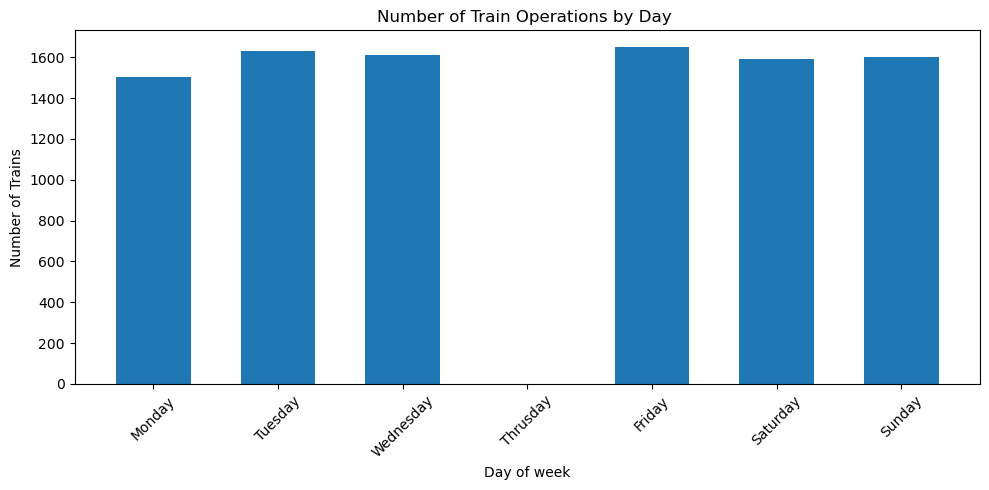

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(day_count.index, day_count.values, width=0.6)

plt.title('Number of Train Operations by Day ')
plt.xlabel('Day of week')
plt.ylabel('Number of Trains')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
top_sources =df['Source_Station_Name'].value_counts().head(10)
print(top_sources)

Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: count, dtype: int64


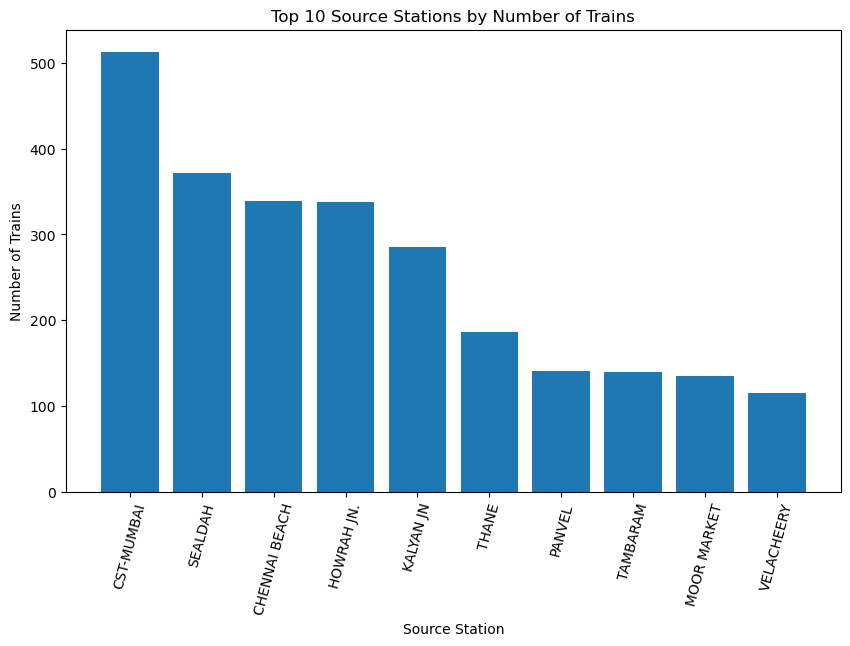

In [34]:
plt.figure(figsize=(10, 6))

plt.bar(top_sources.index, top_sources.values)

plt.title('Top 10 Source Stations by Number of Trains')
plt.xlabel('Source Station')
plt.ylabel('Number of Trains')

plt.xticks(rotation=75)

plt.show()

In [35]:
top_destinations = df['Destination_Station_Name'].value_counts().head(10)
print(top_destinations)

Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
THANE            194
PANVEL           144
TAMBARAM         140
MOOR MARKET      132
VELACHEERY       118
Name: count, dtype: int64


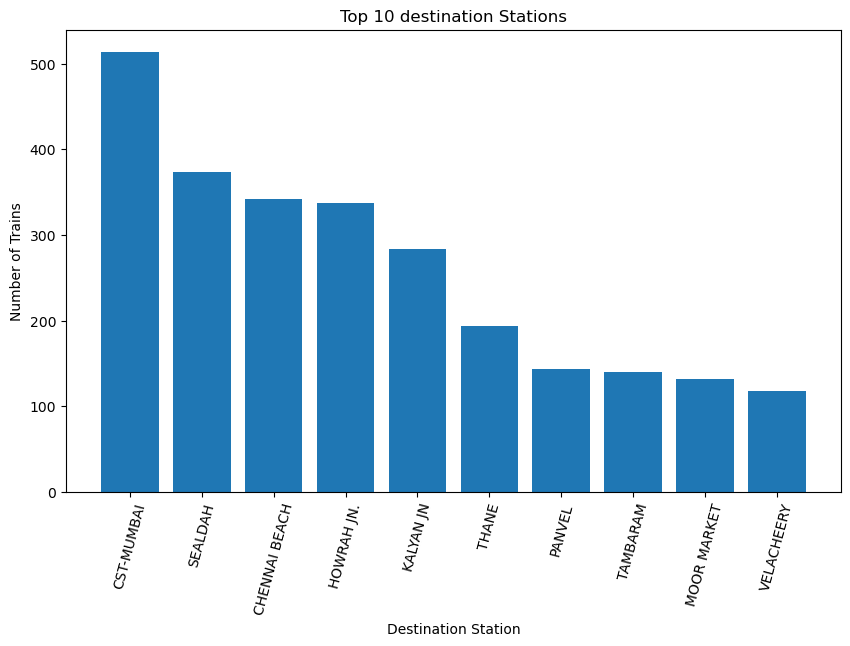

In [36]:
plt.figure(figsize=(10,6))
plt.bar(top_destinations.index, top_destinations.values)
plt.title('Top 10 destination Stations')
plt.xlabel('Destination Station')
plt.ylabel('Number of Trains')

plt.xticks(rotation=75)
plt.show()

In [37]:
routes = df.groupby(
    ['Source_Station_Name', 'Destination_Station_Name']
).size().sort_values(ascending=False)

print(routes.head(10))

Source_Station_Name  Destination_Station_Name
CHENNAI BEACH        TAMBARAM                    137
TAMBARAM             CHENNAI BEACH               137
CST-MUMBAI           PANVEL                       94
PANVEL               CST-MUMBAI                   93
RAVLI JN             CST-MUMBAI                   90
CST-MUMBAI           RAVLI JN                     90
VELACHEERY           CHENNAI BEACH                89
CHENNAI BEACH        VELACHEERY                   87
CST-MUMBAI           THANE                        77
THANE                CST-MUMBAI                   72
dtype: int64


In [38]:
top_routes = routes.head(10).reset_index(name='Train_Count')

print(top_routes)

  Source_Station_Name Destination_Station_Name  Train_Count
0       CHENNAI BEACH                 TAMBARAM          137
1            TAMBARAM            CHENNAI BEACH          137
2          CST-MUMBAI                   PANVEL           94
3              PANVEL               CST-MUMBAI           93
4            RAVLI JN               CST-MUMBAI           90
5          CST-MUMBAI                 RAVLI JN           90
6          VELACHEERY            CHENNAI BEACH           89
7       CHENNAI BEACH               VELACHEERY           87
8          CST-MUMBAI                    THANE           77
9               THANE               CST-MUMBAI           72


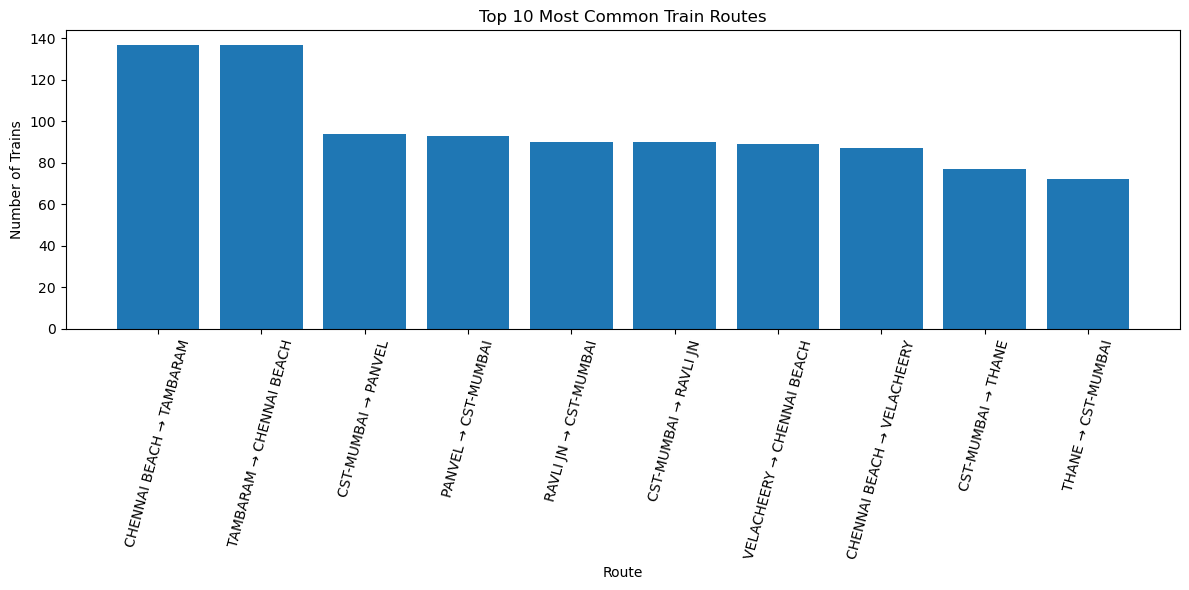

In [39]:
plt.figure(figsize=(12, 6))

route_labels = (
    top_routes['Source_Station_Name'] + 
    ' → ' + 
    top_routes['Destination_Station_Name']
)

plt.bar(route_labels, top_routes['Train_Count'])

plt.title('Top 10 Most Common Train Routes')
plt.xlabel('Route')
plt.ylabel('Number of Trains')

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [40]:
day_order=['Monday','Tuesday','Wednesday','Thrusday','Friday','Saturday','Sunday']
day_count = df['days'].value_counts().reindex(day_order)
print(day_count)

days
Monday       1503.0
Tuesday      1628.0
Wednesday    1612.0
Thrusday        NaN
Friday       1649.0
Saturday     1593.0
Sunday       1602.0
Name: count, dtype: float64


In [41]:
type_count = df['operating_Type'].value_counts()
print(type_count)

operating_Type
weekday    7918
weekend    3195
Name: count, dtype: int64


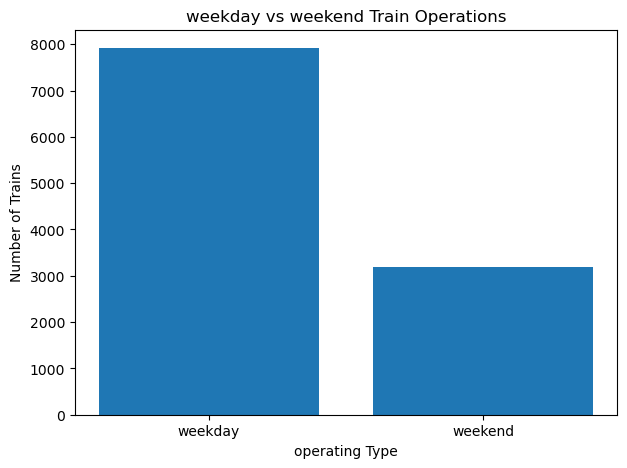

In [42]:
plt.figure(figsize=(7,5))
plt.bar(type_count.index, type_count.values)
plt.title('weekday vs weekend Train Operations')
plt.xlabel('operating Type')
plt.ylabel('Number of Trains')
plt.show()

In [43]:
average_trains = day_count.mean()
print("Average trains per day:", average_trains)
day_difference =day_count-average_trains
print(day_difference.sort_values(ascending=False))

Average trains per day: 1597.8333333333333
days
Friday       51.166667
Tuesday      30.166667
Wednesday    14.166667
Sunday        4.166667
Saturday     -4.833333
Monday      -94.833333
Thrusday           NaN
Name: count, dtype: float64


In [44]:
day_number=pd.Series(range(1,8), index=day_order)
correlation = day_number.corr(day_count)
print("Correlation between day number and train count:",correlation)

Correlation between day number and train count: 0.44162267317375425


In [45]:
source_count = df['Source_Station_Name'].value_counts()
print("Top 10 Source Stations:")
print(source_count.head(10))
print("Most common source station:")
print(source_count.idxmax())
print("Number of Trains:")
print(source_count.max())

Top 10 Source Stations:
Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: count, dtype: int64
Most common source station:
CST-MUMBAI
Number of Trains:
513


In [46]:
destination_count = df['Destination_Station_Name'].value_counts()
print("Top 10 Destination Stations:")
print(destination_count.head(10))
print("Most common destination station:")
print(destination_count.idxmax())
print("Number of trains:")
print(destination_count.max())


Top 10 Destination Stations:
Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
THANE            194
PANVEL           144
TAMBARAM         140
MOOR MARKET      132
VELACHEERY       118
Name: count, dtype: int64
Most common destination station:
CST-MUMBAI
Number of trains:
514


In [47]:
type_count = df['operating_Type'].value_counts()

print("Weekday vs Weekend:")
print(type_count)

Weekday vs Weekend:
operating_Type
weekday    7918
weekend    3195
Name: count, dtype: int64


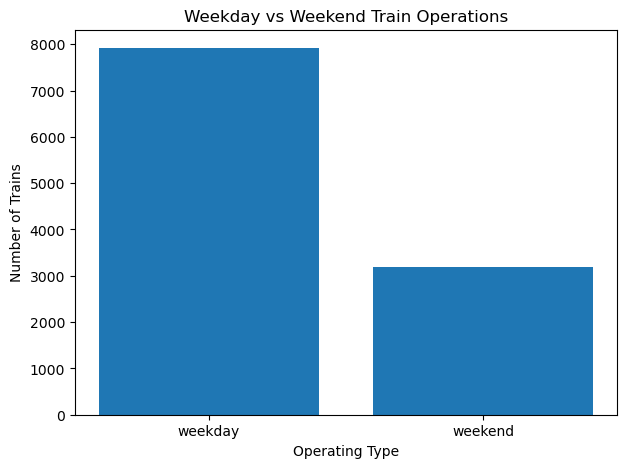

In [48]:
plt.figure(figsize=(7, 5))

plt.bar(type_count.index, type_count.values)

plt.title('Weekday vs Weekend Train Operations')
plt.xlabel('Operating Type')
plt.ylabel('Number of Trains')

plt.show()

In [49]:
import seaborn as sns
top_sources = df['Source_Station_Name'].value_counts().head(10).index
top_destinations=df['Destination_Station_Name'].value_counts().head(10).index
heatmap_data = pd.crosstab(
    df['Source_Station_Name'],
    df['Destination_Station_Name'],)
heatmap_data = heatmap_data.loc[
heatmap_data.index.intersection(top_sources),
heatmap_data.columns.intersection(top_destinations)
]
print(heatmap_data)
    

Destination_Station_Name  CHENNAI BEACH  CST-MUMBAI  HOWRAH JN.  KALYAN JN  \
Source_Station_Name                                                          
CHENNAI BEACH                         0           0           0          0   
CST-MUMBAI                            0           0           5         66   
HOWRAH JN.                            0           5           0          0   
KALYAN JN                             0          70           0          0   
MOOR MARKET                           0           0           0          0   
PANVEL                                0          93           0          0   
SEALDAH                               0           0           0          0   
TAMBARAM                            137           0           0          0   
THANE                                 0          72           0          2   
VELACHEERY                           89           0           0          0   

Destination_Station_Name  MOOR MARKET  PANVEL  SEALDAH  TAMBARA

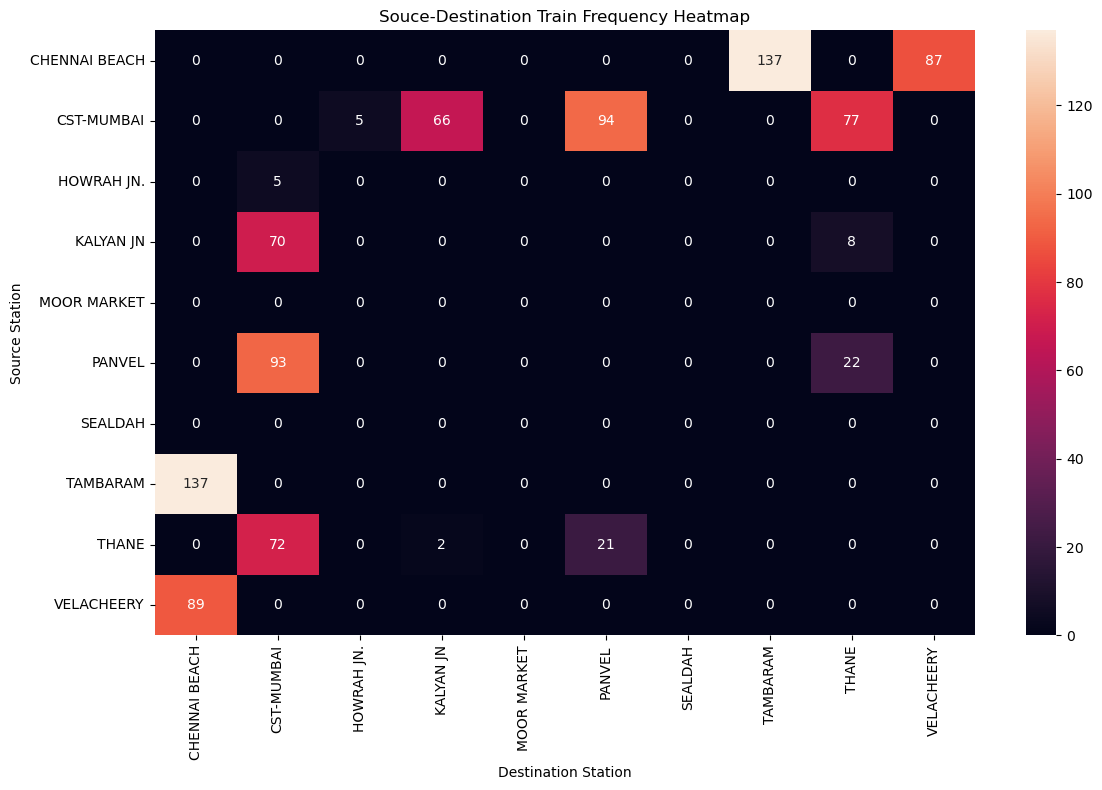

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(
    heatmap_data, annot=True, fmt='d')
plt.title('Souce-Destination Train Frequency Heatmap')
plt.xlabel('Destination Station')
plt.ylabel('Source Station')
plt.tight_layout()
plt.show()

+# Railway Data Engineering Analysis

## 1. Introduction

This project analyzes railway train data to understand train operations,
source stations, destination stations, operating days, and frequently
used train routes.

## 2. Dataset Overview

The dataset contains information about train numbers, train names,
source stations, destination stations, and operating days.

The dataset was explored using Python and Pandas.

## 3. Data Cleaning

The dataset was checked for missing values and inconsistent values.

The operating day names were standardized by removing the extra
character from values such as "Mondayd", "Tuesdayd", etc.

Station names were also standardized to maintain a consistent format.

## 4. Data Transformation

A new column named `Operating_Type` was created.

Trains operating from Monday to Friday were categorized as "Weekday",
while trains operating on Saturday and Sunday were categorized as
"Weekend".

## 5. Key Statistics

The most common source stations and destination stations were identified
using value counts.

CST-MUMBAI was identified as the most common destination station,
with 514 train entries.

The average number of train operations per day was approximately
1597.83.

## 6. Day-wise Train Distribution

The number of train operations for each day was analyzed.

Friday recorded the highest number of train operations with 1649,
while Monday recorded the lowest with 1503.

The distribution shows that train operations are relatively high
throughout the week.

## 7. Weekday vs Weekend Analysis

The analysis shows that weekday train operations are considerably
higher than weekend operations.

This indicates that railway services in the dataset are more concentrated
during weekdays.

## 8. Source and Destination Station Analysis

CST-MUMBAI is one of the busiest stations in the dataset.

Other frequently occurring stations include SEALDAH, CHENNAI BEACH,
HOWRAH JN., KALYAN JN., THANE, PANVEL, TAMBARAM, MOOR MARKET,
and VELACHEERY.

## 9. Route Analysis

The source-destination analysis identified several frequently operated
routes.

Some high-frequency routes include:

- CHENNAI BEACH → TAMBARAM
- TAMBARAM → CHENNAI BEACH
- CST-MUMBAI → PANVEL
- PANVEL → CST-MUMBAI
- THANE → CST-MUMBAI
- KALYAN JN. → CST-MUMBAI
- CST-MUMBAI → THANE
- VELACHEERY → CHENNAI BEACH

## 10. Visualizations

The following visualizations were created:

1. Number of Train Operations by Day
2. Top Source Stations
3. Top Destination Stations
4. Weekday vs Weekend Train Operations
5. Source-Destination Train Frequency Heatmap
6. Top 10 Most Common Train Routes

## 11. Key Insights

- Friday has the highest number of train operations.
- Monday has the lowest number of train operations.
- Weekday operations are significantly higher than weekend operations.
- CST-MUMBAI is a major station in the dataset.
- Several routes show high-frequency two-way train operations.
- The heatmap highlights important source-destination relationships.

## 12. Recommendations

Based on the analysis, railway planners can:

- Focus resources on high-frequency stations.
- Optimize train scheduling on heavily used routes.
- Analyze weekday demand to improve peak-period services.
- Review weekend services to determine whether additional trains
  are required on specific routes.
- Use source-destination patterns for better resource allocation.

## 13. Conclusion

This project demonstrates how Python, Pandas, Matplotlib, and Seaborn
can be used for data exploration, cleaning, transformation,
aggregation, visualization, and reporting.

The analysis provides useful insights into train frequency,
station activity, operating-day patterns, and major railway routes.